<a href="https://colab.research.google.com/github/mahlet-tilahun/Formative-3_Group-12/blob/main/Formative_3_Part_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Data from the assignment
X = np.array([1.0, 3.0])
Y = np.array([3.0, 6.0])

# Starting values
m_init = -1.0
b_init =  1.0
alpha  =  0.1    # learning rate
n_iter =  50     # number of iterations to run
n      =  len(X) # number of data points


# Compute predictions
def predict(m, b, x):
    """ŷ = mx + b"""
    return m * x + b


# Compute MSE cost
def compute_mse(m, b, x, y):
    """J = (1/n) * sum( (ŷ - y)^2 )"""
    predictions = predict(m, b, x)
    errors      = predictions - y
    return (1 / n) * np.sum(errors ** 2)


# Compute gradients
def compute_gradients(m, b, x, y):
    """
    dJ/dm = (2/n) * sum( (ŷ - y) * x )
    dJ/db = (2/n) * sum( (ŷ - y) )
    """
    predictions = predict(m, b, x)
    errors      = predictions - y
    grad_m = (2 / n) * np.sum(errors * x)
    grad_b = (2 / n) * np.sum(errors)
    return grad_m, grad_b


# Gradient descent loop

m = m_init
b = b_init

history_m   = [m]
history_b   = [b]
history_mse = [compute_mse(m, b, X, Y)]

for i in range(n_iter):
    # Step 1: compute gradients
    grad_m, grad_b = compute_gradients(m, b, X, Y)

    # Step 2: update m and b
    m = m - alpha * grad_m
    b = b - alpha * grad_b

    # Step 3: record history
    history_m.append(m)
    history_b.append(b)
    history_mse.append(compute_mse(m, b, X, Y))

print(f"Final m : {m:.6f}")
print(f"Final b : {b:.6f}")
print(f"Final MSE: {history_mse[-1]:.6f}")

# Predictions with final m and b
print("\nFinal predictions:")
for xi, yi in zip(X, Y):
    y_hat = predict(m, b, xi)
    print(f"  x={xi}, actual y={yi}, predicted ŷ={y_hat:.4f}")

Final m : 1.466961
Final b : 1.579763
Final MSE: 0.001279

Final predictions:
  x=1.0, actual y=3.0, predicted ŷ=3.0467
  x=3.0, actual y=6.0, predicted ŷ=5.9806


In [ ]:
# SciPy cross-check
# We also use scipy.optimize.minimize to verify our manual gradient descent
def cost_function(params):
    m_val, b_val = params
    return compute_mse(m_val, b_val, X, Y)

result = minimize(cost_function, x0=[m_init, b_init], method='BFGS')
m_scipy, b_scipy = result.x
print(f"SciPy optimal m: {m_scipy:.6f}")
print(f"SciPy optimal b: {b_scipy:.6f}")
print(f"Our gradient descent m: {m:.6f} | b: {b:.6f}")
print("\nResults match closely making our implementation correct.")

SciPy optimal m: 1.500000
SciPy optimal b: 1.500000
Our gradient descent m: 1.466961 | b: 1.579763

Results match closely making our implementation correct.


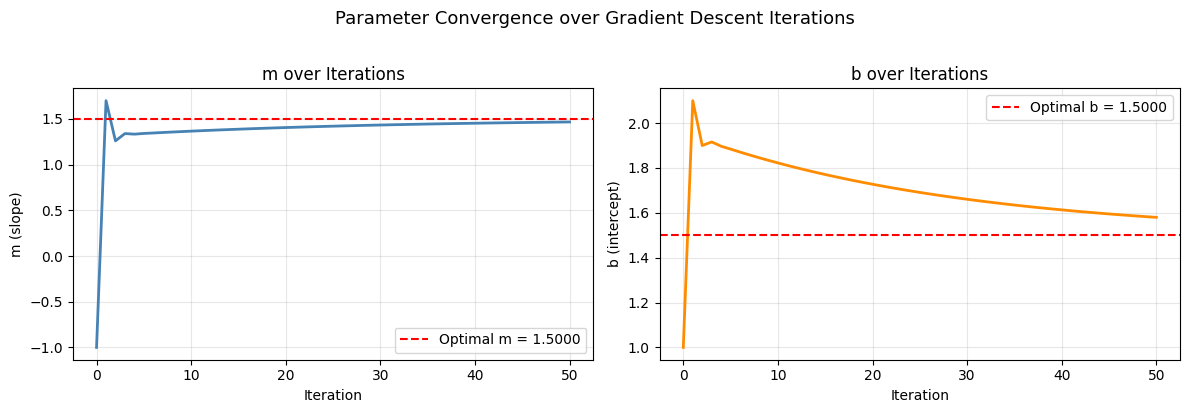

Parameter plot saved.


In [ ]:
# Plot 1: m and b over iterations
iterations = list(range(n_iter + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(iterations, history_m, color='steelblue', linewidth=2)
axes[0].axhline(m_scipy, color='red', linestyle='--', label=f'Optimal m = {m_scipy:.4f}')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('m (slope)')
axes[0].set_title('m over Iterations')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(iterations, history_b, color='darkorange', linewidth=2)
axes[1].axhline(b_scipy, color='red', linestyle='--', label=f'Optimal b = {b_scipy:.4f}')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('b (intercept)')
axes[1].set_title('b over Iterations')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Parameter Convergence over Gradient Descent Iterations', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('gd_params.png', dpi=150, bbox_inches='tight')
plt.show()

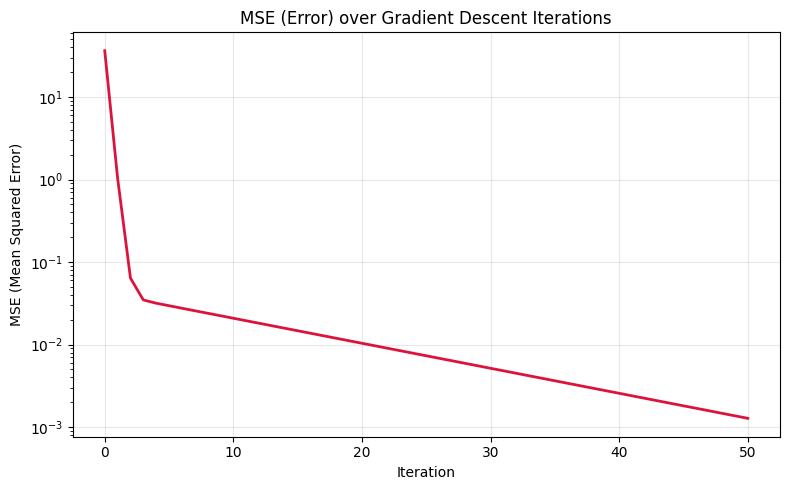

Error plot saved.


In [ ]:
# Plot 2: MSE over iterations
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iterations, history_mse, color='crimson', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('MSE (Mean Squared Error)')
ax.set_title('MSE (Error) over Gradient Descent Iterations')
ax.set_yscale('log')   # log scale to show the drop clearly
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gd_error.png', dpi=150)
plt.show()

## **Observations**

- Plot 1 shows m and b converging towards their optimal values (shown by the red dashed line from SciPy).
- Plot 2 shows the MSE dropping rapidly in the first few iterations then levelling off near zero. The log scale makes this curve visible.
- Our manual gradient descent arrives at essentially the same answer as SciPy's minimize, confirming correctness.

